
# Notebook 4 — Multi-match Planning Under Congestion

This notebook extends the **Football Decision Engine** from single-match optimization to a **three-match planning horizon**.

The objective is no longer _"who should start today?"_ but:

> **How should exposure be allocated across the next three matches under tactical, risk and fatigue constraints?**

The notebook is intentionally written as an **elite-portfolio / club-ready analysis artifact**:
- three matches with different strategic importance
- accumulated fatigue between fixtures
- formation-constrained XI selection in each match
- controlled use of `limit_minutes`
- total exposure analysis across the horizon
- executive conclusions for performance and football decision-making

> This notebook is fully executed for interpretability and review.



## 1. Analytical framing

The planning problem is modeled as a **rolling horizon allocation problem**.

For each match, the system must jointly decide:
- the starting XI under a valid **4-3-3**
- which players are protected with `limit_minutes`
- which players are deprioritized to `bench`

The core logic remains aligned with the project philosophy:

**Prediction → Policy → Optimization → Decision System**

The main extension introduced here is **fatigue propagation**:
- starting a match increases next-match fatigue the most
- `limit_minutes` increases fatigue moderately
- `bench` allows recovery
- short turnarounds penalize repeated exposure, especially for high-risk players

This makes the notebook closer to the real operational questions handled by:
- performance departments
- medical and return-to-play workflows
- matchday planning teams
- technical staff balancing upside vs availability


In [142]:

import math

# Global plotting style (recommended)
import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

import numpy as np
import pandas as pd

try:
    from scipy.optimize import linear_sum_assignment
except ImportError as exc:
    raise ImportError(
        "This notebook requires scipy. Install it with: pip install scipy"
    ) from exc

plt.rcParams["figure.dpi"] = 130
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)



## 2. Construct the squad snapshot

The squad is kept consistent with the previous notebooks, but now each player also receives:

- an eligibility map for tactical slots
- a fatigue state initialized at zero
- an exposure counter across the horizon

The planning horizon uses a fixed **4-3-3**:

`GK, RB, RCB, LCB, LB, DM, RCM, LCM, RW, ST, LW`


In [143]:

slots = ["GK", "RB", "RCB", "LCB", "LB", "DM", "RCM", "LCM", "RW", "ST", "LW"]

squad = pd.DataFrame(
    [
        ("P01","GK1","GK","Goalkeeper",0.08,0.64,"Starting goalkeeper",["GK"]),
        ("P02","GK2","GK","Goalkeeper",0.12,0.34,"Backup goalkeeper",["GK"]),
        ("P03","RB1","RB","Defence",0.24,0.71,"Reliable full-back",["RB"]),
        ("P04","CB1","CB","Defence",0.21,0.84,"Core centre-back",["RCB","LCB"]),
        ("P05","CB2","CB","Defence",0.33,0.76,"Complementary centre-back",["RCB","LCB"]),
        ("P06","LB1","LB","Defence",0.28,0.72,"Two-way full-back",["LB"]),
        ("P07","DM1","DM","Midfield",0.29,0.81,"Ball-winning anchor",["DM","RCM","LCM"]),
        ("P08","CM1","CM","Midfield",0.38,0.74,"Progressor",["RCM","LCM"]),
        ("P09","AM1","AM","Midfield",0.42,0.86,"Primary creator",["RCM","LCM"]),
        ("P10","RW1","RW","Attack",0.74,0.93,"Explosive winger, monitored load",["RW"]),
        ("P11","LW1","LW","Attack",0.69,0.82,"High-upside wide threat",["LW"]),
        ("P12","ST1","ST","Attack",0.58,0.89,"First-choice striker",["ST"]),
        ("P13","FB2","FB","Defence",0.54,0.55,"Rotation full-back",["RB","LB"]),
        ("P14","CB3","CB","Defence",0.63,0.60,"Risky depth centre-back",["RCB","LCB"]),
        ("P15","CM2","CM","Midfield",0.65,0.77,"High-value midfielder with elevated risk",["RCM","LCM"]),
        ("P16","W2","W","Attack",0.81,0.68,"Direct winger with high exposure",["RW","LW"]),
        ("P17","ST2","ST","Attack",0.31,0.57,"Bench striker",["ST"]),
        ("P18","AM2","AM","Midfield",0.72,0.79,"Creative option with risk flag",["RCM","LCM"]),
        ("P19","DM2","DM","Midfield",0.61,0.52,"Protective midfielder, low upside",["DM","RCM","LCM"]),
        ("P20","CB4","CB","Defence",0.46,0.49,"Depth centre-back",["RCB","LCB"]),
        ("P21","W3","W","Attack",0.77,0.44,"Low-value high-risk winger",["RW","LW"]),
    ],
    columns=[
        "player_id","player_name","position","unit","risk_score","value_score","context_note","eligible_slots"
    ],
)

squad["fatigue"] = 0.0
squad["starts_used"] = 0

squad


,player_id,player_name,position,unit,risk_score,value_score,context_note,eligible_slots,fatigue,starts_used
0,P01,GK1,GK,Goalkeeper,0.08,0.64,Starting goalkeeper,[GK],0.0,0
1,P02,GK2,GK,Goalkeeper,0.12,0.34,Backup goalkeeper,[GK],0.0,0
2,P03,RB1,RB,Defence,0.24,0.71,Reliable full-back,[RB],0.0,0
3,P04,CB1,CB,Defence,0.21,0.84,Core centre-back,"[RCB, LCB]",0.0,0
4,P05,CB2,CB,Defence,0.33,0.76,Complementary centre-back,"[RCB, LCB]",0.0,0
5,P06,LB1,LB,Defence,0.28,0.72,Two-way full-back,[LB],0.0,0
6,P07,DM1,DM,Midfield,0.29,0.81,Ball-winning anchor,"[DM, RCM, LCM]",0.0,0
7,P08,CM1,CM,Midfield,0.38,0.74,Progressor,"[RCM, LCM]",0.0,0
8,P09,AM1,AM,Midfield,0.42,0.86,Primary creator,"[RCM, LCM]",0.0,0
9,P10,RW1,RW,Attack,0.74,0.93,"Explosive winger, monitored load",[RW],0.0,0


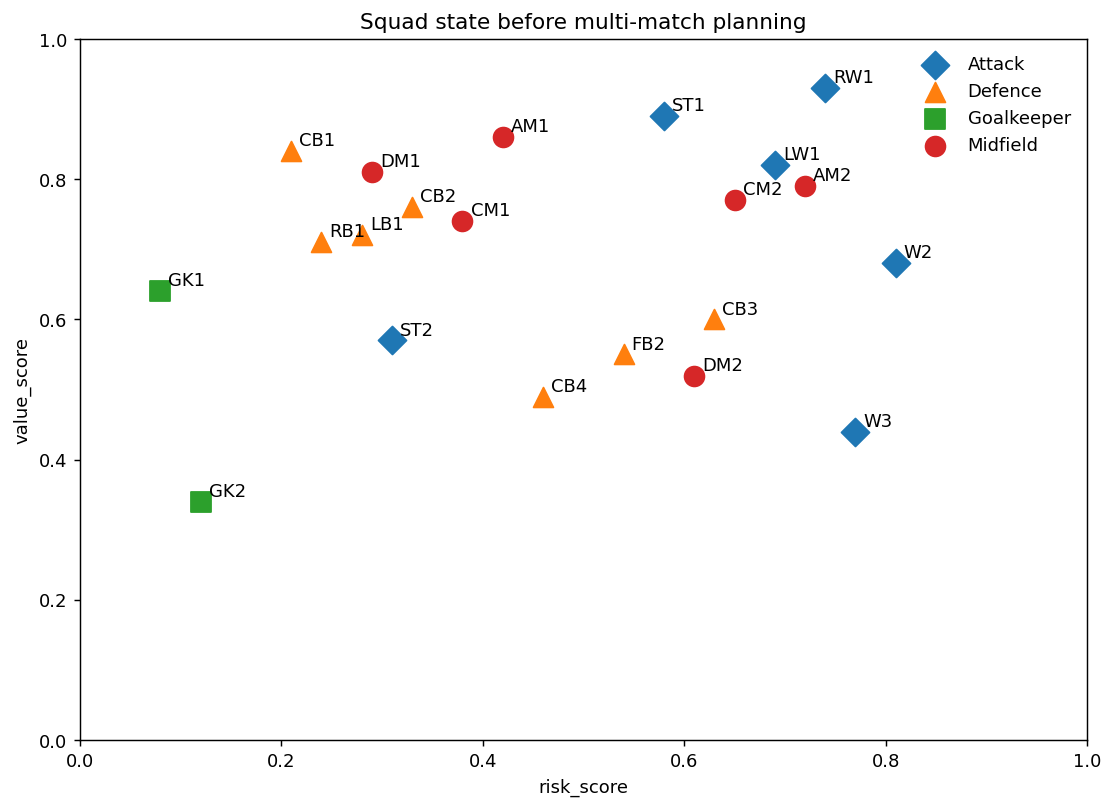

In [144]:

fig, ax = plt.subplots(figsize=(10, 7))

style_map = {
    "Attack": dict(marker="D", label="Attack"),
    "Defence": dict(marker="^", label="Defence"),
    "Goalkeeper": dict(marker="s", label="Goalkeeper"),
    "Midfield": dict(marker="o", label="Midfield"),
}

for unit, style in style_map.items():
    subset = squad[squad["unit"] == unit]
    ax.scatter(
        subset["risk_score"],
        subset["value_score"],
        s=120,
        marker=style["marker"],
        label=style["label"],
    )
    for _, row in subset.iterrows():
        ax.text(row["risk_score"] + 0.008, row["value_score"] + 0.008, row["player_name"], fontsize=10)

ax.set_title("Squad state before multi-match planning")
ax.set_xlabel("risk_score")
ax.set_ylabel("value_score")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(frameon=False)
plt.show()



## 3. Define the three-match horizon

The horizon is intentionally heterogeneous:

- **Match 1**: high-importance league game against a strong opponent
- **Match 2**: cup fixture against a more manageable opponent with short recovery
- **Match 3**: another important league game, where accumulated fatigue already matters

This is the kind of congestion profile where myopic one-match logic becomes insufficient.


In [145]:

schedule = pd.DataFrame(
    [
        ("M1", "League vs Top-4 rival", 1.30, 0.85, 4),
        ("M2", "Cup vs mid-table opponent", 0.95, 0.55, 3),
        ("M3", "League vs direct rival", 1.20, 0.78, 5),
    ],
    columns=["match_id", "match_label", "match_importance", "opponent_strength", "recovery_days"],
)

schedule


,match_id,match_label,match_importance,opponent_strength,recovery_days
0,M1,League vs Top-4 rival,1.30,0.85,4
1,M2,Cup vs mid-table opponent,0.95,0.55,3
2,M3,League vs direct rival,1.20,0.78,5


In [146]:

policy_snapshot = pd.DataFrame(
    [
        {
            "policy_name": "multi_match_planning_policy",
            "high_risk_threshold": 0.70,
            "high_value_threshold": 0.60,
            "risk_penalty": 0.50,
            "formation": "4-3-3",
            "n_starters": 11,
            "max_limit_minutes": 3,
        }
    ]
)

policy_snapshot


,policy_name,high_risk_threshold,high_value_threshold,risk_penalty,formation,n_starters,max_limit_minutes
0,multi_match_planning_policy,0.7,0.6,0.5,4-3-3,11,3



## 4. Build the planning logic

For notebook portability, the planning example uses an **assignment-based optimizer** with fatigue-aware utilities.

Conceptually, this remains aligned with the project decision layer:
- maximize squad utility
- enforce a valid tactical shape
- protect high-risk players when appropriate
- reason jointly about exposure and role coverage

### Utility design

For player *i* in match *t*:

- **contextual value** increases with match importance and opponent profile
- **risk penalty** reduces the upside of fragile players
- **fatigue penalty** increases with accumulated exposure
- **repeat-start penalty** discourages overloading the same players across the horizon

The optimizer proceeds match by match, updating fatigue after each decision set.


In [147]:
def slot_bonus(slot: str) -> float:
    return {
        "GK": 0.01,
        "DM": 0.02,
        "ST": 0.015,
        "RCM": 0.01,
        "LCM": 0.01,
    }.get(slot, 0.0)


def compute_contextual_value(row: pd.Series, match: pd.Series) -> float:
    base = row["value_score"]
    contextual = base * (0.82 + 0.32 * match["match_importance"])

    if row["unit"] == "Attack":
        contextual += 0.05 * match["opponent_strength"]
    elif row["unit"] == "Defence":
        contextual += 0.03 * match["opponent_strength"]
    else:
        contextual += 0.02 * match["match_importance"]

    return contextual


def score_start(row: pd.Series, match: pd.Series) -> float:
    contextual = compute_contextual_value(row, match)
    fatigue_penalty = (0.35 + 0.18 * match["match_importance"]) * row["fatigue"]
    risk_penalty = (0.42 + 0.10 * match["opponent_strength"]) * row["risk_score"]

    starts_penalty = (0.11 if row["risk_score"] >= 0.65 else 0.035) * row["starts_used"]
    cup_rotation_penalty = 0.08 * row["starts_used"] if match["match_id"] == "M2" else 0.0
    congestion_penalty = 0.08 if (
        row["risk_score"] >= 0.68
        and row["starts_used"] >= 1
        and match["recovery_days"] <= 4
    ) else 0.0

    return contextual - risk_penalty - fatigue_penalty - starts_penalty - cup_rotation_penalty - congestion_penalty


def score_limit(row: pd.Series, match: pd.Series) -> float:
    contextual = compute_contextual_value(row, match)
    fatigue_penalty = (0.16 + 0.08 * match["match_importance"]) * row["fatigue"]
    risk_penalty = (0.24 + 0.06 * match["opponent_strength"]) * row["risk_score"]
    cup_support_bonus = 0.02 if (
        match["match_id"] == "M2"
        and row["starts_used"] >= 1
        and row["risk_score"] >= 0.55
    ) else 0.0

    return 0.76 * contextual - risk_penalty - fatigue_penalty + cup_support_bonus


def score_bench(row: pd.Series, match: pd.Series) -> float:
    rest_utility = 0.04 + 0.12 * row["risk_score"] + 0.10 * row["fatigue"]
    if match["match_id"] == "M2" and row["starts_used"] >= 1:
        rest_utility += 0.03
    return rest_utility


def assign_starting_xi(state: pd.DataFrame, match: pd.Series):
    n_players = len(state)
    n_slots = len(slots)
    utility_matrix = np.full((n_players, n_slots), -1e6)

    for i, row in state.iterrows():
        base_start_utility = score_start(row, match)
        for j, slot in enumerate(slots):
            if slot not in row["eligible_slots"]:
                continue

            utility = base_start_utility + slot_bonus(slot)

            if row["position"] == "ST" and row["risk_score"] > 0.55 and match["match_id"] == "M2":
                utility -= 0.12

            if row["position"] in ["RW", "LW", "W"] and row["risk_score"] > 0.70 and match["match_id"] == "M2":
                utility -= 0.10

            utility_matrix[i, j] = utility

    row_idx, col_idx = linear_sum_assignment(-utility_matrix)
    valid_mask = utility_matrix[row_idx, col_idx] > -1e5

    row_idx = row_idx[valid_mask]
    col_idx = col_idx[valid_mask]

    starters = set(row_idx.tolist())
    assigned_slots = {i: slots[j] for i, j in zip(row_idx, col_idx)}

    return starters, assigned_slots


def optimize_match(state: pd.DataFrame, match: pd.Series, max_limit_minutes: int = 3) -> pd.DataFrame:
    starters, assigned_slots = assign_starting_xi(state, match)

    remaining_rows = []
    for i, row in state.iterrows():
        if i in starters:
            continue

        remaining_rows.append(
            {
                "idx": i,
                "limit_score": score_limit(row, match),
                "bench_score": score_bench(row, match),
                "value_score": row["value_score"],
            }
        )

    remaining_df = pd.DataFrame(remaining_rows)
    remaining_df["limit_margin"] = remaining_df["limit_score"] - remaining_df["bench_score"]
    remaining_df = remaining_df.sort_values(by=["limit_margin", "value_score"], ascending=[False, False])

    limit_candidates = set(remaining_df.head(max_limit_minutes)["idx"].tolist())
    limit_candidates = {
        idx for idx in limit_candidates
        if float(remaining_df.loc[remaining_df["idx"] == idx, "limit_margin"].iloc[0]) > -0.05
    }

    output = state.copy()

    # --- IMPORTANT: initialize text columns with object dtype ---
    output["match_id"] = pd.Series([match["match_id"]] * len(output), dtype="object")
    output["match_label"] = pd.Series([match["match_label"]] * len(output), dtype="object")
    output["assigned_slot"] = pd.Series([None] * len(output), dtype="object")
    output["policy_decision"] = pd.Series([None] * len(output), dtype="object")
    output["final_decision"] = pd.Series([None] * len(output), dtype="object")

    output["match_importance"] = match["match_importance"]
    output["opponent_strength"] = match["opponent_strength"]

    start_utilities = []
    limit_utilities = []
    bench_utilities = []
    contextual_values = []
    base_scores = []
    policy_decisions = []
    final_decisions = []
    final_utilities = []
    changed_flags = []

    for i, row in state.iterrows():
        contextual_value = compute_contextual_value(row, match)
        base_score = row["value_score"] - 0.50 * row["risk_score"]

        start_utility = score_start(row, match)
        limit_utility = score_limit(row, match)
        bench_utility = score_bench(row, match)

        if row["risk_score"] >= 0.70 and row["value_score"] < 0.60:
            policy_decision = "bench"
        elif row["risk_score"] >= 0.70 and row["value_score"] >= 0.60:
            policy_decision = "limit_minutes"
        else:
            policy_decision = "start"

        if i in starters:
            final_decision = "start"
            final_utility = start_utility
            output.loc[i, "assigned_slot"] = assigned_slots[i]
        elif i in limit_candidates:
            final_decision = "limit_minutes"
            final_utility = limit_utility
        else:
            final_decision = "bench"
            final_utility = bench_utility

        start_utilities.append(start_utility)
        limit_utilities.append(limit_utility)
        bench_utilities.append(bench_utility)
        contextual_values.append(contextual_value)
        base_scores.append(base_score)
        policy_decisions.append(policy_decision)
        final_decisions.append(final_decision)
        final_utilities.append(final_utility)
        changed_flags.append(policy_decision != final_decision)

    output["contextual_value"] = contextual_values
    output["base_score"] = base_scores
    output["start_utility"] = start_utilities
    output["limit_utility"] = limit_utilities
    output["bench_utility"] = bench_utilities
    output["policy_decision"] = pd.Series(policy_decisions, dtype="object")
    output["final_decision"] = pd.Series(final_decisions, dtype="object")
    output["final_utility"] = final_utilities
    output["changed_by_optimization"] = changed_flags

    return output


def update_fatigue(state: pd.DataFrame, decisions: pd.DataFrame, recovery_days: int) -> pd.DataFrame:
    updated = state.copy()

    for i, row in decisions.iterrows():
        fatigue = float(updated.loc[i, "fatigue"])

        if row["final_decision"] == "start":
            fatigue += 0.30
            updated.loc[i, "starts_used"] += 1
            if row["risk_score"] >= 0.70:
                fatigue += 0.04
        elif row["final_decision"] == "limit_minutes":
            fatigue += 0.16
        else:
            fatigue -= 0.12

        fatigue -= 0.035 * recovery_days
        updated.loc[i, "fatigue"] = min(1.0, max(0.0, fatigue))

    return updated


## 5. Run the rolling-horizon planner


In [148]:

planning_history = []
state = squad.copy()

for _, match in schedule.iterrows():
    match_decisions = optimize_match(state, match, max_limit_minutes=3)
    planning_history.append(match_decisions)
    state = update_fatigue(state, match_decisions, int(match["recovery_days"]))

planning = pd.concat(planning_history, ignore_index=True)

planning.head()


,player_id,player_name,position,unit,risk_score,value_score,context_note,eligible_slots,fatigue,starts_used,match_id,match_label,assigned_slot,policy_decision,final_decision,match_importance,opponent_strength,contextual_value,base_score,start_utility,limit_utility,bench_utility,final_utility,changed_by_optimization
0,P01,GK1,GK,Goalkeeper,0.08,0.64,Starting goalkeeper,[GK],0.0,0,M1,League vs Top-4 rival,GK,start,start,1.3,0.85,0.81704,0.600,0.77664,0.597670,0.0496,0.77664,False
1,P02,GK2,GK,Goalkeeper,0.12,0.34,Backup goalkeeper,[GK],0.0,0,M1,League vs Top-4 rival,None,start,bench,1.3,0.85,0.44624,0.280,0.38564,0.304222,0.0544,0.05440,True
2,P03,RB1,RB,Defence,0.24,0.71,Reliable full-back,[RB],0.0,0,M1,League vs Top-4 rival,RB,start,start,1.3,0.85,0.90306,0.590,0.78186,0.616486,0.0688,0.78186,False
3,P04,CB1,CB,Defence,0.21,0.84,Core centre-back,"[RCB, LCB]",0.0,0,M1,League vs Top-4 rival,RCB,start,start,1.3,0.85,1.06374,0.735,0.95769,0.747332,0.0652,0.95769,False
4,P05,CB2,CB,Defence,0.33,0.76,Complementary centre-back,"[RCB, LCB]",0.0,0,M1,League vs Top-4 rival,LCB,start,start,1.3,0.85,0.96486,0.595,0.79821,0.637264,0.0796,0.79821,False


In [149]:

overall_summary = pd.DataFrame(
    [
        {"metric": "Matches planned", "value": schedule.shape[0]},
        {"metric": "Squad size", "value": squad.shape[0]},
        {"metric": "Formation", "value": "4-3-3"},
        {"metric": "Starts allocated", "value": int((planning["final_decision"] == "start").sum())},
        {"metric": "Limit_minutes allocated", "value": int((planning["final_decision"] == "limit_minutes").sum())},
        {"metric": "Bench allocations", "value": int((planning["final_decision"] == "bench").sum())},
        {"metric": "Decision overrides", "value": int(planning["changed_by_optimization"].sum())},
    ]
)

overall_summary


,metric,value
0,Matches planned,3
1,Squad size,21
2,Formation,4-3-3
3,Starts allocated,33
4,Limit_minutes allocated,9
5,Bench allocations,21
6,Decision overrides,29



## 6. Inspect the final actions match by match


In [150]:

for match_id in schedule["match_id"]:
    match_table = (
        planning.loc[planning["match_id"] == match_id, [
            "player_name",
            "position",
            "risk_score",
            "value_score",
            "policy_decision",
            "final_decision",
            "assigned_slot",
            "base_score",
            "final_utility",
            "changed_by_optimization",
        ]]
        .sort_values(by=["final_decision", "assigned_slot", "final_utility"], ascending=[True, True, False])
        .reset_index(drop=True)
    )

    print(f"=== {match_id} ===")
    display(match_table)


=== M1 ===


,player_name,position,risk_score,value_score,policy_decision,final_decision,assigned_slot,base_score,final_utility,changed_by_optimization
0,W2,W,0.81,0.68,limit_minutes,bench,None,0.275,0.137200,True
1,W3,W,0.77,0.44,bench,bench,None,0.055,0.132400,False
2,CB3,CB,0.63,0.60,start,bench,None,0.285,0.115600,True
3,DM2,DM,0.61,0.52,start,bench,None,0.215,0.113200,True
4,FB2,FB,0.54,0.55,start,bench,None,0.280,0.104800,True
5,CB4,CB,0.46,0.49,start,bench,None,0.260,0.095200,True
6,GK2,GK,0.12,0.34,start,bench,None,0.280,0.054400,True
7,CM2,CM,0.65,0.77,start,limit_minutes,None,0.445,0.553917,True
8,AM2,AM,0.72,0.79,limit_minutes,limit_minutes,None,0.430,0.552334,False
9,ST2,ST,0.31,0.57,start,limit_minutes,None,0.415,0.477525,True


=== M2 ===


,player_name,position,risk_score,value_score,policy_decision,final_decision,assigned_slot,base_score,final_utility,changed_by_optimization
0,W3,W,0.77,0.44,bench,bench,None,0.055,0.132400,False
1,AM2,AM,0.72,0.79,limit_minutes,bench,None,0.430,0.128400,True
2,CB3,CB,0.63,0.60,start,bench,None,0.285,0.115600,True
3,DM2,DM,0.61,0.52,start,bench,None,0.215,0.113200,True
4,FB2,FB,0.54,0.55,start,bench,None,0.280,0.104800,True
5,CB4,CB,0.46,0.49,start,bench,None,0.260,0.095200,True
6,GK2,GK,0.12,0.34,start,bench,None,0.280,0.054400,True
7,ST1,ST,0.58,0.89,start,limit_minutes,None,0.600,0.605074,True
8,RW1,RW,0.74,0.93,limit_minutes,limit_minutes,None,0.560,0.586123,False
9,CM1,CM,0.38,0.74,start,limit_minutes,None,0.550,0.505078,True


=== M3 ===


,player_name,position,risk_score,value_score,policy_decision,final_decision,assigned_slot,base_score,final_utility,changed_by_optimization
0,W2,W,0.81,0.68,limit_minutes,bench,None,0.275,0.160700,True
1,W3,W,0.77,0.44,bench,bench,None,0.055,0.132400,False
2,CB3,CB,0.63,0.60,start,bench,None,0.285,0.115600,True
3,DM2,DM,0.61,0.52,start,bench,None,0.215,0.113200,True
4,FB2,FB,0.54,0.55,start,bench,None,0.280,0.104800,True
5,CB4,CB,0.46,0.49,start,bench,None,0.260,0.095200,True
6,GK2,GK,0.12,0.34,start,bench,None,0.280,0.054400,True
7,CM1,CM,0.38,0.74,start,limit_minutes,None,0.550,0.531346,True
8,CM2,CM,0.65,0.77,start,limit_minutes,None,0.445,0.481361,True
9,ST2,ST,0.31,0.57,start,limit_minutes,None,0.415,0.407265,True


In [151]:

decision_mix = (
    planning.groupby(["match_id", "final_decision"])
    .size()
    .rename("n_players")
    .reset_index()
    .sort_values(["match_id", "final_decision"])
)

decision_mix


,match_id,final_decision,n_players
0,M1,bench,7
1,M1,limit_minutes,3
2,M1,start,11
3,M2,bench,7
4,M2,limit_minutes,3
5,M2,start,11
6,M3,bench,7
7,M3,limit_minutes,3
8,M3,start,11



## 7. Starting XI by match

This is the most important football-facing output: who starts, and in which tactical slot.


In [152]:

for match_id in schedule["match_id"]:
    lineup = (
        planning.loc[
            (planning["match_id"] == match_id) & (planning["final_decision"] == "start"),
            [
                "assigned_slot",
                "player_name",
                "position",
                "unit",
                "risk_score",
                "value_score",
                "base_score",
                "final_utility",
                "context_note",
            ],
        ]
        .sort_values("assigned_slot")
        .reset_index(drop=True)
    )

    print(f"Optimized XI — {match_id}")
    display(lineup)


Optimized XI — M1


,assigned_slot,player_name,position,unit,risk_score,value_score,base_score,final_utility,context_note
0,DM,DM1,DM,Midfield,0.29,0.81,0.665,0.88071,Ball-winning anchor
1,GK,GK1,GK,Goalkeeper,0.08,0.64,0.600,0.77664,Starting goalkeeper
2,LB,LB1,LB,Defence,0.28,0.72,0.580,0.77402,Two-way full-back
3,LCB,CB2,CB,Defence,0.33,0.76,0.595,0.79821,Complementary centre-back
4,LCM,CM1,CM,Midfield,0.38,0.74,0.550,0.74874,Progressor
5,LW,LW1,LW,Attack,0.69,0.82,0.475,0.70757,High-upside wide threat
6,RB,RB1,RB,Defence,0.24,0.71,0.590,0.78186,Reliable full-back
7,RCB,CB1,CB,Defence,0.21,0.84,0.735,0.95769,Core centre-back
8,RCM,AM1,AM,Midfield,0.42,0.86,0.650,0.87686,Primary creator
9,RW,RW1,RW,Attack,0.74,0.93,0.560,0.81828,"Explosive winger, monitored load"


Optimized XI — M2


,assigned_slot,player_name,position,unit,risk_score,value_score,base_score,final_utility,context_note
0,DM,DM1,DM,Midfield,0.29,0.81,0.665,0.59333,Ball-winning anchor
1,GK,GK1,GK,Goalkeeper,0.08,0.64,0.600,0.50200,Starting goalkeeper
2,LB,LB1,LB,Defence,0.28,0.72,0.580,0.49442,Two-way full-back
3,LCB,CB2,CB,Defence,0.33,0.76,0.595,0.51563,Complementary centre-back
4,LCM,CM2,CM,Midfield,0.65,0.77,0.445,0.56531,High-value midfielder with elevated risk
5,LW,LW1,LW,Attack,0.69,0.82,0.475,0.26807,High-upside wide threat
6,RB,RB1,RB,Defence,0.24,0.71,0.590,0.50218,Reliable full-back
7,RCB,CB1,CB,Defence,0.21,0.84,0.735,0.66255,Core centre-back
8,RCM,AM1,AM,Midfield,0.42,0.86,0.650,0.58778,Primary creator
9,RW,W2,W,Attack,0.81,0.68,0.275,0.40707,Direct winger with high exposure


Optimized XI — M3


,assigned_slot,player_name,position,unit,risk_score,value_score,base_score,final_utility,context_note
0,DM,DM1,DM,Midfield,0.29,0.81,0.665,0.58389,Ball-winning anchor
1,GK,GK1,GK,Goalkeeper,0.08,0.64,0.600,0.48379,Starting goalkeeper
2,LB,LB1,LB,Defence,0.28,0.72,0.580,0.47991,Two-way full-back
3,LCB,CB2,CB,Defence,0.33,0.76,0.595,0.50317,Complementary centre-back
4,LCM,AM1,AM,Midfield,0.42,0.86,0.650,0.57935,Primary creator
5,LW,LW1,LW,Attack,0.69,0.82,0.475,0.26173,High-upside wide threat
6,RB,RB1,RB,Defence,0.24,0.71,0.590,0.48779,Reliable full-back
7,RCB,CB1,CB,Defence,0.21,0.84,0.735,0.65925,Core centre-back
8,RCM,AM2,AM,Midfield,0.72,0.79,0.430,0.61660,Creative option with risk flag
9,RW,RW1,RW,Attack,0.74,0.93,0.560,0.53587,"Explosive winger, monitored load"


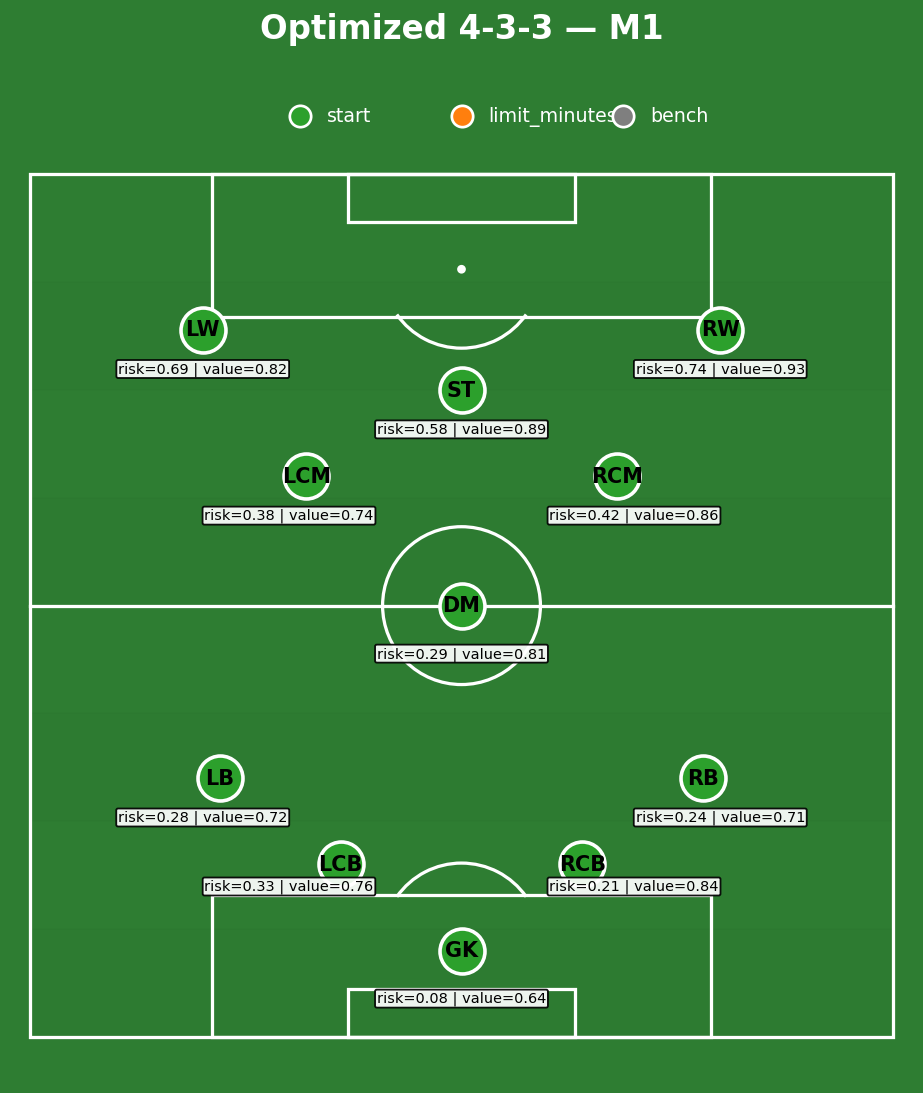

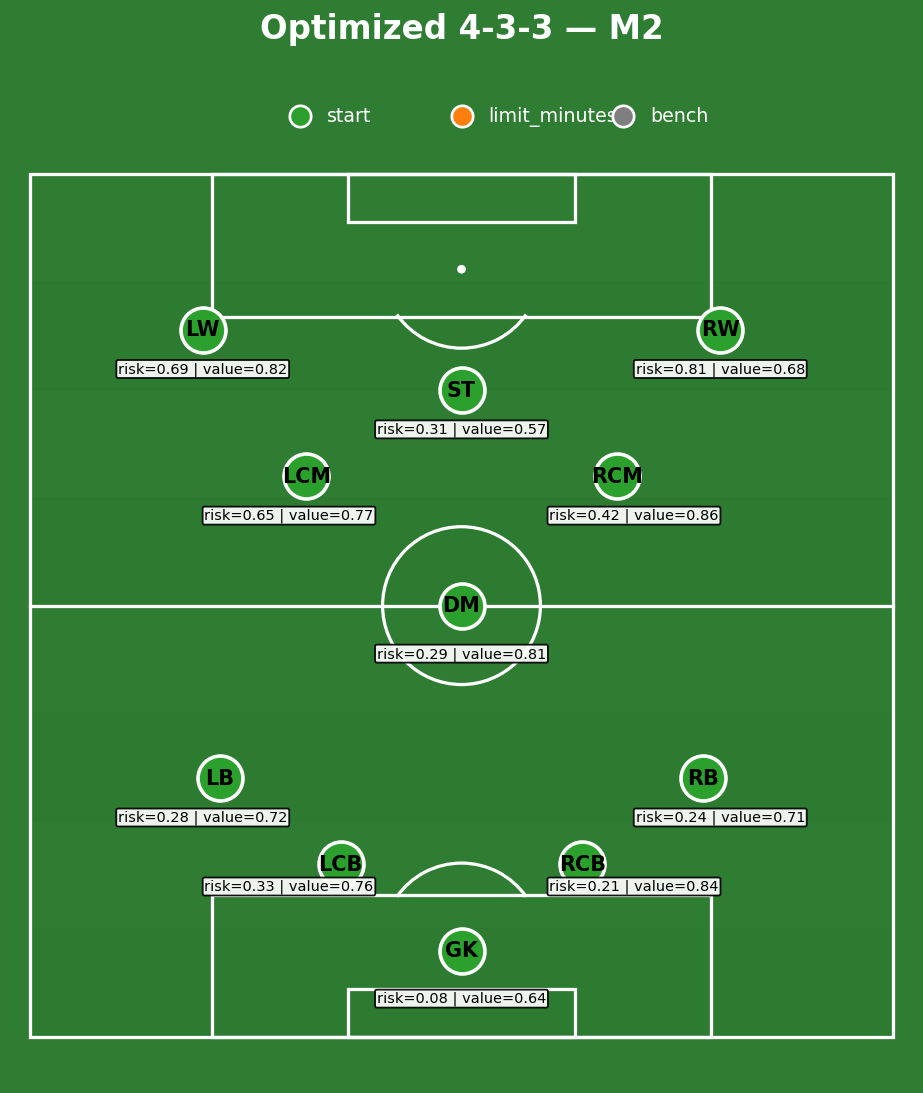

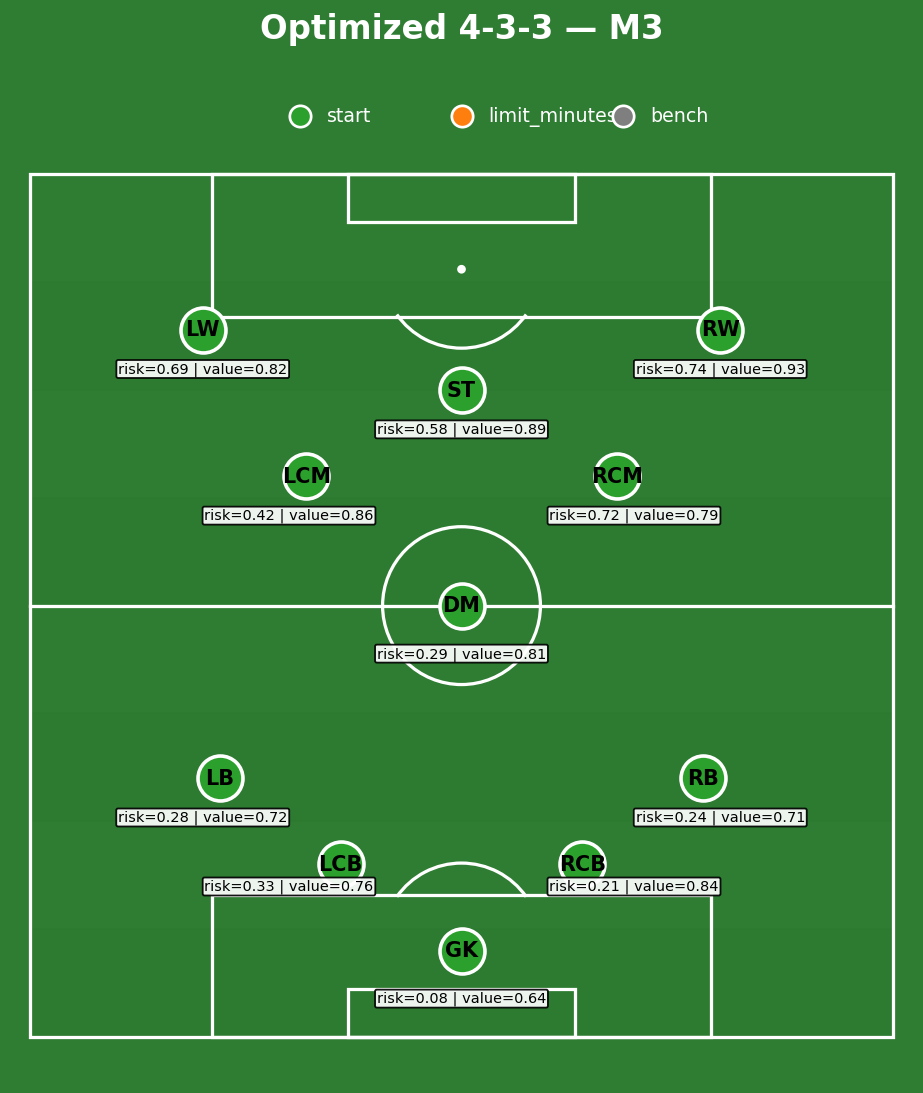

In [153]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, Arc


pitch_y = {
    "GK": 10,
    "RB": 30,
    "RCB": 20,
    "LCB": 20,
    "LB": 30,
    "DM": 50,
    "RCM": 65,
    "LCM": 65,
    "RW": 82,
    "ST": 75,
    "LW": 82,
}

pitch_x = {
    "GK": 50,
    "RB": 78,
    "RCB": 64,
    "LCB": 36,
    "LB": 22,
    "DM": 50,
    "RCM": 68,
    "LCM": 32,
    "RW": 80,
    "ST": 50,
    "LW": 20,
}


def draw_pitch(ax):
    pitch_color = "#2e7d32"
    stripe_color = "#2a7330"
    line_color = "white"

    ax.set_facecolor(pitch_color)

    stripes = np.linspace(0, 100, 9)
    for i in range(len(stripes)-1):
        if i % 2 == 0:
            ax.add_patch(Rectangle((0, stripes[i]), 100, stripes[i+1]-stripes[i],
                                   color=stripe_color, alpha=0.2, zorder=0))

    ax.add_patch(Rectangle((0, 0), 100, 100, fill=False, edgecolor=line_color, lw=1.8))
    ax.plot([0, 100], [50, 50], color=line_color, lw=1.8)

    ax.add_patch(Circle((50, 50), 9.15, fill=False, edgecolor=line_color, lw=1.8))
    ax.add_patch(Circle((50, 50), 0.5, color=line_color))

    ax.add_patch(Rectangle((21.1, 0), 57.8, 16.5, fill=False, edgecolor=line_color, lw=1.8))
    ax.add_patch(Rectangle((21.1, 83.5), 57.8, 16.5, fill=False, edgecolor=line_color, lw=1.8))

    ax.add_patch(Rectangle((36.8, 0), 26.4, 5.5, fill=False, edgecolor=line_color, lw=1.8))
    ax.add_patch(Rectangle((36.8, 94.5), 26.4, 5.5, fill=False, edgecolor=line_color, lw=1.8))

    ax.add_patch(Circle((50, 11), 0.4, color=line_color))
    ax.add_patch(Circle((50, 89), 0.4, color=line_color))

    ax.add_patch(Arc((50, 11), 18.3, 18.3, theta1=35, theta2=145, color=line_color, lw=1.8))
    ax.add_patch(Arc((50, 89), 18.3, 18.3, theta1=215, theta2=325, color=line_color, lw=1.8))

    ax.set_xlim(-2, 102)
    ax.set_ylim(-5, 112)
    ax.set_aspect("equal")
    ax.axis("off")


def add_legend(ax):
    xs = [0.32, 0.50, 0.68]
    labels = ["start", "limit_minutes", "bench"]
    colors = ["#2ca02c", "#ff7f0e", "#7f7f7f"]

    for x, label, color in zip(xs, labels, colors):
        ax.scatter([x], [0.955], s=140, color=color,
                   edgecolor="white", linewidth=1.5,
                   transform=ax.transAxes, zorder=6)
        ax.text(x + 0.03, 0.955, label,
                transform=ax.transAxes,
                color="white", fontsize=10.5,
                va="center")


# 🔑 CLAVE: offsets personalizados para evitar solapes
def label_offset(slot):
    offsets = {
        "LCB": (-6, -3),
        "RCB": (6, -3),
        "LB": (-2, -5),
        "RB": (2, -5),
        "LCM": (-2, -5),
        "RCM": (2, -5),
        "DM": (0, -6),
        "GK": (0, -6),
        "ST": (0, -5),
        "LW": (0, -5),
        "RW": (0, -5),
    }
    return offsets.get(slot, (0, -5))


def draw_pitch_lineup(match_id: str):

    lineup = planning.loc[
        (planning["match_id"] == match_id) &
        (planning["assigned_slot"].notna())
    ].copy()

    colors = {
        "start": "#2ca02c",
        "limit_minutes": "#ff7f0e",
        "bench": "#7f7f7f",
    }

    fig, ax = plt.subplots(figsize=(7.2, 9.2), facecolor="#2e7d32")
    draw_pitch(ax)

    ax.set_title(f"Optimized 4-3-3 — {match_id}",
                 fontsize=18, fontweight="bold", color="white", pad=18)

    add_legend(ax)

    for _, row in lineup.iterrows():

        slot = row["assigned_slot"]
        x = pitch_x[slot]
        y = pitch_y[slot]

        decision = row.get("final_decision", "start")
        color = colors.get(decision, "#2ca02c")

        # player
        ax.scatter(x, y, s=620, color=color,
                   edgecolor="white", linewidth=2, zorder=3)

        # slot label
        ax.text(x, y, slot,
                ha="center", va="center",
                fontsize=11.5, fontweight="bold",
                color="black", zorder=4)

        # offset label
        dx, dy = label_offset(slot)

        ax.text(
            x + dx,
            y + dy,
            f"risk={row['risk_score']:.2f} | value={row['value_score']:.2f}",
            ha="center",
            fontsize=8,
            bbox=dict(
                facecolor="white",
                alpha=0.92,
                boxstyle="round,pad=0.12"  
            ),
            zorder=4
)

    plt.tight_layout()
    plt.show()


# --- RUN ---
draw_pitch_lineup("M1")
draw_pitch_lineup("M2")
draw_pitch_lineup("M3")


## 8. Exposure totals across the horizon

This section evaluates who carries the greatest workload and where the system deliberately rotates.


In [154]:

exposure = (
    planning.assign(
        start_flag=(planning["final_decision"] == "start").astype(int),
        limit_flag=(planning["final_decision"] == "limit_minutes").astype(int),
        bench_flag=(planning["final_decision"] == "bench").astype(int),
        exposure_points=np.select(
            [
                planning["final_decision"] == "start",
                planning["final_decision"] == "limit_minutes",
                planning["final_decision"] == "bench",
            ],
            [1.00, 0.50, 0.00],
            default=0.0,
        ),
    )
    .groupby(
        ["player_name", "position", "unit", "risk_score", "value_score", "context_note"],
        as_index=False,
    )
    .agg(
        starts=("start_flag", "sum"),
        limit_minutes=("limit_flag", "sum"),
        bench=("bench_flag", "sum"),
        total_exposure=("exposure_points", "sum"),
    )
    .sort_values(by=["total_exposure", "value_score"], ascending=[False, False])
    .reset_index(drop=True)
)

exposure.head(15)


,player_name,position,unit,risk_score,value_score,context_note,starts,limit_minutes,bench,total_exposure
0,AM1,AM,Midfield,0.42,0.86,Primary creator,3,0,0,3.0
1,CB1,CB,Defence,0.21,0.84,Core centre-back,3,0,0,3.0
2,LW1,LW,Attack,0.69,0.82,High-upside wide threat,3,0,0,3.0
3,DM1,DM,Midfield,0.29,0.81,Ball-winning anchor,3,0,0,3.0
4,CB2,CB,Defence,0.33,0.76,Complementary centre-back,3,0,0,3.0
5,LB1,LB,Defence,0.28,0.72,Two-way full-back,3,0,0,3.0
6,RB1,RB,Defence,0.24,0.71,Reliable full-back,3,0,0,3.0
7,GK1,GK,Goalkeeper,0.08,0.64,Starting goalkeeper,3,0,0,3.0
8,RW1,RW,Attack,0.74,0.93,"Explosive winger, monitored load",2,1,0,2.5
9,ST1,ST,Attack,0.58,0.89,First-choice striker,2,1,0,2.5


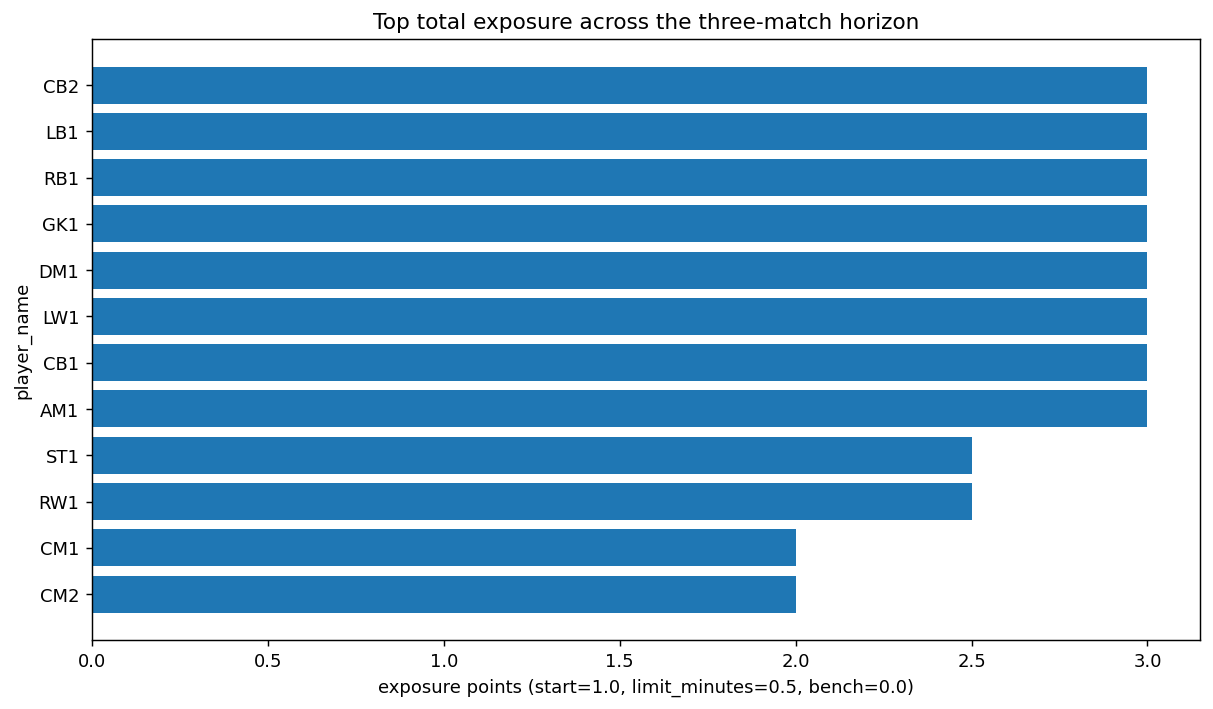

In [155]:

fig, ax = plt.subplots(figsize=(11, 6))
top_exposure = exposure.head(12).sort_values("total_exposure", ascending=True)

ax.barh(top_exposure["player_name"], top_exposure["total_exposure"])
ax.set_title("Top total exposure across the three-match horizon")
ax.set_xlabel("exposure points (start=1.0, limit_minutes=0.5, bench=0.0)")
ax.set_ylabel("player_name")
plt.show()


In [156]:

fatigue_state = squad.copy()
fatigue_snapshots = []

for _, match in schedule.iterrows():
    decisions = (
        planning[planning["match_id"] == match["match_id"]]
        .copy()
        .reset_index(drop=True)
    )
    fatigue_state = fatigue_state.reset_index(drop=True)

    fatigue_snapshots.append(
        fatigue_state[["player_name", "fatigue"]].assign(match_id=match["match_id"], stage="pre_match")
    )
    fatigue_state = update_fatigue(fatigue_state, decisions, int(match["recovery_days"]))
    fatigue_snapshots.append(
        fatigue_state[["player_name", "fatigue"]].assign(match_id=match["match_id"], stage="post_match")
    )

fatigue_snapshots = pd.concat(fatigue_snapshots, ignore_index=True)

fatigue_post = (
    fatigue_snapshots[fatigue_snapshots["stage"] == "post_match"]
    .pivot(index="player_name", columns="match_id", values="fatigue")
    .fillna(0.0)
)

fatigue_post.head()


match_id,M1,M2,M3
player_name,,,
AM1,0.16,0.355,0.480
AM2,0.02,0.000,0.165
CB1,0.16,0.355,0.480
CB2,0.16,0.355,0.480
CB3,0.00,0.000,0.000


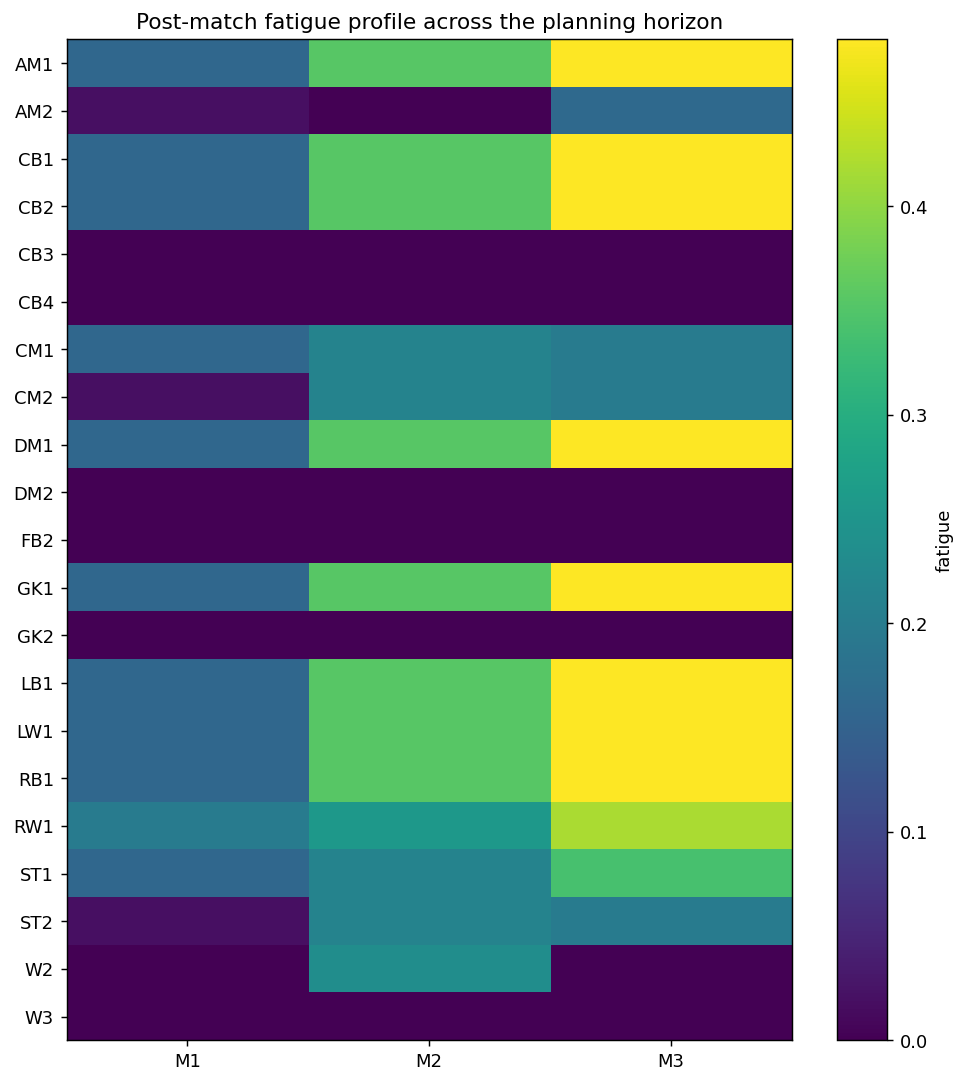

In [157]:

fig, ax = plt.subplots(figsize=(9, 10))
im = ax.imshow(fatigue_post.values, aspect="auto")

ax.set_title("Post-match fatigue profile across the planning horizon")
ax.set_xticks(range(len(fatigue_post.columns)))
ax.set_xticklabels(fatigue_post.columns)
ax.set_yticks(range(len(fatigue_post.index)))
ax.set_yticklabels(fatigue_post.index)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("fatigue")

plt.show()


In [158]:
# Save fatigue heatmap

fig.savefig(
    "../assets/demo/fatigue_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

fig.tight_layout()

print("Saved: assets/demo/fatigue_heatmap.png")

Saved: assets/demo/fatigue_heatmap.png


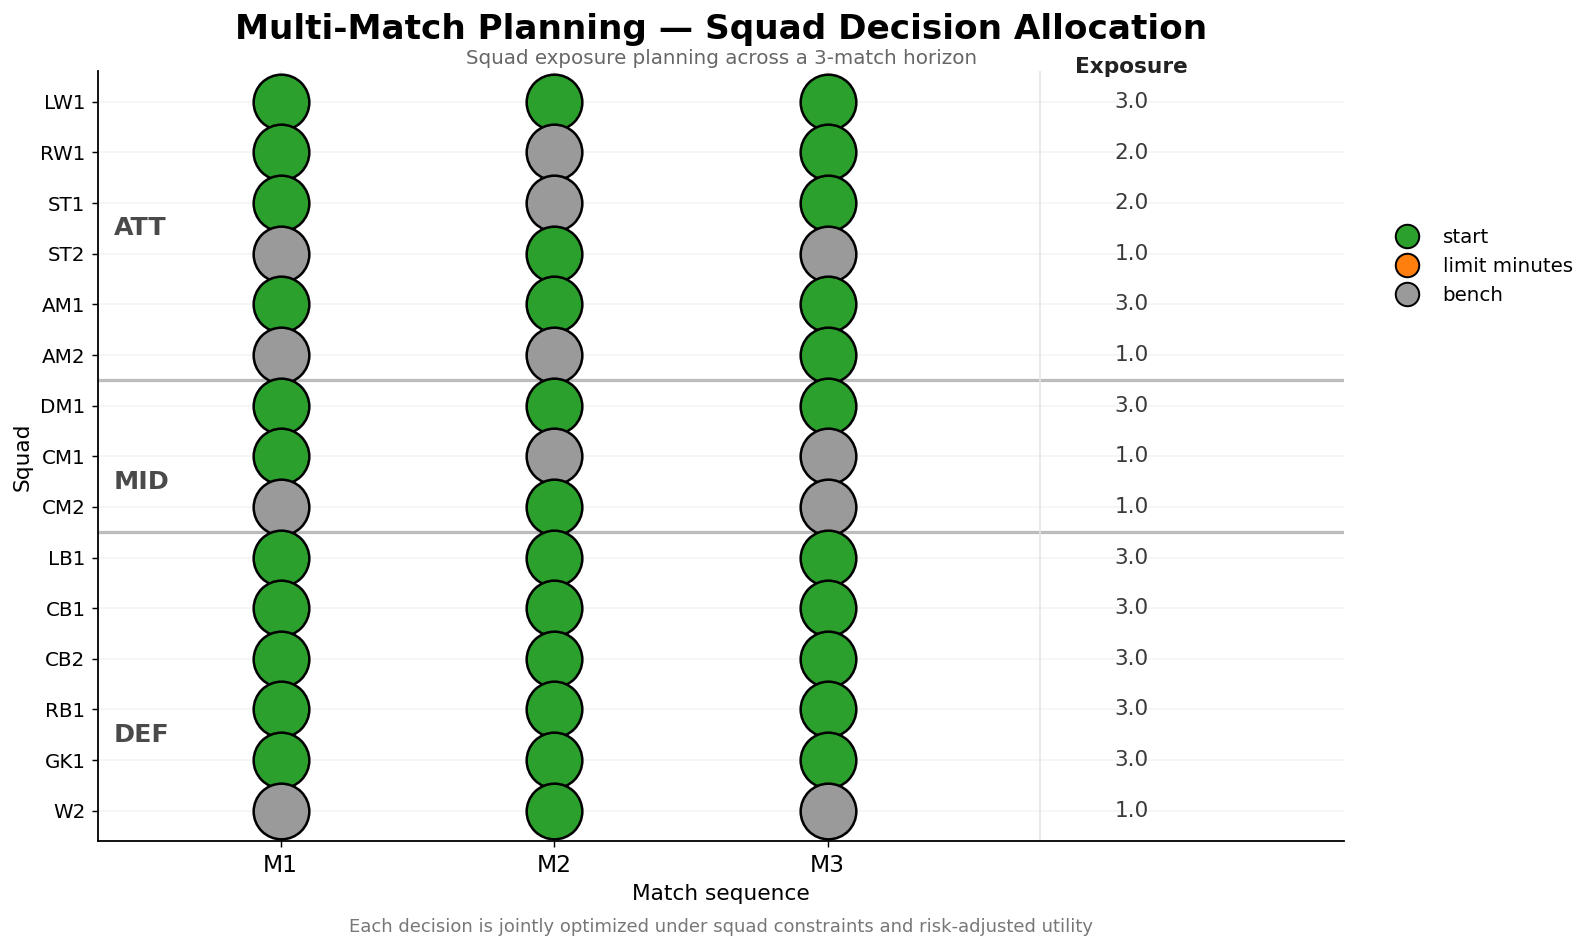

Saved: ../assets/demo/multi_match_planning.png


In [159]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# --- PREP DATA ---

df = planning.copy()
df = df[df["assigned_slot"].notna()].copy()

df_plot = df.pivot_table(
    index="player_name",
    columns="match_id",
    values="final_decision",
    aggfunc="first"
).fillna("bench")

match_order = ["M1", "M2", "M3"]
df_plot = df_plot[[m for m in match_order if m in df_plot.columns]]

# Exposure
exposure_map = {"start": 1.0, "limit_minutes": 0.5, "bench": 0.0}
exposure_table = df_plot.replace(exposure_map)
player_exposure = exposure_table.sum(axis=1)

# --- TACTICAL ORDER ---

tactical_order = [
    # ATT
    "LW1", "RW1", "ST1", "ST2", "AM1", "AM2",
    # MID
    "DM1", "CM1", "CM2",
    # DEF
    "LB1", "CB1", "CB2", "RB1", "GK1",
    # extras
    "W2"
]

df_plot = df_plot.loc[[p for p in tactical_order if p in df_plot.index]]
player_exposure = player_exposure.loc[df_plot.index]

# --- STYLE ---

decision_colors = {
    "start": "#2ca02c",
    "limit_minutes": "#ff7f0e",
    "bench": "#9a9a9a"
}

# Match positions with extra spacing
x_pos = {"M1": 0.0, "M2": 1.8, "M3": 3.6}
x_vals = [x_pos[m] for m in df_plot.columns]

# Exposure column
x_exp = 5.6
y_header = -0.50

fig, ax = plt.subplots(figsize=(13.5, 8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# --- GRID ---

# Vertical guides for matches
for xv in x_vals:
    ax.axvline(xv, color="#ededed", linewidth=1.0, zorder=0)

# Horizontal row guides
for y in range(len(df_plot.index)):
    ax.axhline(y, color="#f5f5f5", linewidth=0.9, zorder=0)

# Tactical separators
for sep in [6, 9]:
    ax.axhline(sep - 0.5, color="#bcbcbc", linewidth=1.8, zorder=1)

# Exposure separator (lighter and thinner)
ax.axvline(x_exp - 0.6, color="#e5e5e5", linewidth=0.9, zorder=1)

# --- TACTICAL LABELS ---

ax.text(
    -1.1, 2.5, "ATT",
    fontsize=14, fontweight="bold",
    color="#4a4a4a", va="center", ha="left"
)
ax.text(
    -1.1, 7.5, "MID",
    fontsize=14, fontweight="bold",
    color="#4a4a4a", va="center", ha="left"
)
ax.text(
    -1.1, 12.5, "DEF",
    fontsize=14, fontweight="bold",
    color="#4a4a4a", va="center", ha="left"
)

# --- SCATTER DECISIONS ---

for y, player in enumerate(df_plot.index):
    for match in df_plot.columns:
        decision = str(df_plot.loc[player, match])

        ax.scatter(
            x_pos[match],
            y,
            s=950,
            color=decision_colors[decision],
            edgecolor="black",
            linewidth=1.4,
            zorder=3
        )

# --- EXPOSURE COLUMN ---

ax.text(
    x_exp,
    y_header,
    "Exposure",
    fontsize=12,
    fontweight="bold",
    ha="center",
    va="bottom",
    color="#222222"
)

for y, player in enumerate(df_plot.index):
    ax.text(
        x_exp,
        y,
        f"{player_exposure.loc[player]:.1f}",
        fontsize=12,
        color="#3a3a3a",
        va="center",
        ha="center"
    )

# --- AXES ---

ax.set_xticks(x_vals)
ax.set_xticklabels(df_plot.columns, fontsize=13)

ax.set_yticks(range(len(df_plot.index)))
ax.set_yticklabels(df_plot.index, fontsize=11)

ax.set_xlim(-1.2, 7.0)
ax.set_ylim(-0.6, len(df_plot.index) - 0.4)
ax.invert_yaxis()

ax.set_xlabel("Match sequence", fontsize=12)
ax.set_ylabel("Squad", fontsize=12)

# Main title
ax.set_title(
    "Multi-Match Planning — Squad Decision Allocation",
    fontsize=19,
    fontweight="bold",
    pad=18
)

# Subtitle: lowered enough to avoid overlap with the title
ax.text(
    0.5,
    1.005,
    "Squad exposure planning across a 3-match horizon",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=11,
    color="#666666"
)

# Optional bottom caption
ax.text(
    0.5,
    -0.10,
    "Each decision is jointly optimized under squad constraints and risk-adjusted utility",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=10,
    color="#777777"
)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.0)
ax.spines["bottom"].set_linewidth(1.0)

# --- LEGEND ---

handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        color="w",
        markerfacecolor=c,
        markeredgecolor="black",
        markeredgewidth=1.1,
        markersize=13,
        label=l.replace("_", " ")
    )
    for l, c in decision_colors.items()
]

ax.legend(
    handles=handles,
    loc="upper left",
    bbox_to_anchor=(1.02, 0.82),
    frameon=False,
    fontsize=11
)

# Layout tuned to preserve top subtitle and bottom caption
plt.subplots_adjust(top=0.88, right=0.80, bottom=0.14, left=0.09)

plt.show()

# --- SAVE ---

os.makedirs("../assets/demo", exist_ok=True)

fig.savefig(
    "../assets/demo/multi_match_planning.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

print("Saved: ../assets/demo/multi_match_planning.png")


## 9. Overrides from policy to planning

This is the strongest decision-systems lens in the notebook.

The policy layer still gives a first recommendation, but the multi-match planner can override it when:
- the tactical slot is scarce
- the player must be protected later in the horizon
- the squad needs rotation in the middle fixture
- the same player would otherwise accumulate excessive load


In [160]:

overrides = (
    planning.loc[planning["changed_by_optimization"], [
        "match_id",
        "player_name",
        "position",
        "risk_score",
        "value_score",
        "policy_decision",
        "final_decision",
        "assigned_slot",
        "base_score",
        "final_utility",
        "context_note",
    ]]
    .sort_values(["match_id", "final_decision", "base_score"], ascending=[True, True, False])
    .reset_index(drop=True)
)

overrides


,match_id,player_name,position,risk_score,value_score,policy_decision,final_decision,assigned_slot,base_score,final_utility,context_note
0,M1,CB3,CB,0.63,0.60,start,bench,None,0.285,0.115600,Risky depth centre-back
1,M1,GK2,GK,0.12,0.34,start,bench,None,0.280,0.054400,Backup goalkeeper
2,M1,FB2,FB,0.54,0.55,start,bench,None,0.280,0.104800,Rotation full-back
3,M1,W2,W,0.81,0.68,limit_minutes,bench,None,0.275,0.137200,Direct winger with high exposure
4,M1,CB4,CB,0.46,0.49,start,bench,None,0.260,0.095200,Depth centre-back
5,M1,DM2,DM,0.61,0.52,start,bench,None,0.215,0.113200,"Protective midfielder, low upside"
6,M1,CM2,CM,0.65,0.77,start,limit_minutes,None,0.445,0.553917,High-value midfielder with elevated risk
7,M1,ST2,ST,0.31,0.57,start,limit_minutes,None,0.415,0.477525,Bench striker
8,M1,RW1,RW,0.74,0.93,limit_minutes,start,RW,0.560,0.818280,"Explosive winger, monitored load"
9,M2,AM2,AM,0.72,0.79,limit_minutes,bench,None,0.430,0.128400,Creative option with risk flag


In [161]:

transition_summary = (
    planning.groupby(["policy_decision", "final_decision"])
    .size()
    .reset_index(name="n_allocations")
    .sort_values("n_allocations", ascending=False)
    .reset_index(drop=True)
)

transition_summary


,policy_decision,final_decision,n_allocations
0,start,start,29
1,start,bench,15
2,start,limit_minutes,7
3,limit_minutes,start,4
4,bench,bench,3
5,limit_minutes,bench,3
6,limit_minutes,limit_minutes,2



## 10. Final action mix by unit


In [162]:

unit_mix = (
    planning.pivot_table(
        index="unit",
        columns="final_decision",
        values="player_id",
        aggfunc="count",
        fill_value=0,
    )
    .reset_index()
)

unit_mix


final_decision,unit,bench,limit_minutes,start
0,Attack,5,4,9
1,Defence,9,0,12
2,Goalkeeper,3,0,3
3,Midfield,4,5,9


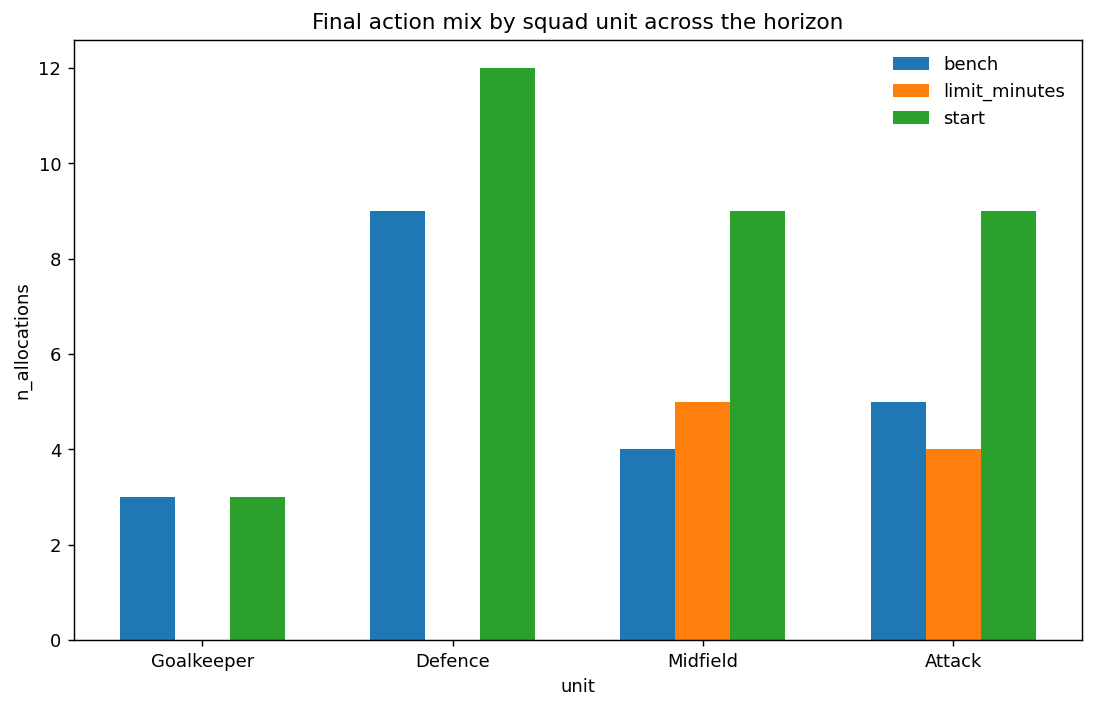

In [163]:
unit_mix_plot = (
    planning.groupby(["unit", "final_decision"])
    .size()
    .rename("n_allocations")
    .reset_index()
)

decision_order = ["bench", "limit_minutes", "start"]
unit_order = ["Goalkeeper", "Defence", "Midfield", "Attack"]

unit_mix_plot["unit"] = pd.Categorical(
    unit_mix_plot["unit"],
    categories=unit_order,
    ordered=True,
)

unit_mix_plot["final_decision"] = pd.Categorical(
    unit_mix_plot["final_decision"],
    categories=decision_order,
    ordered=True,
)

unit_mix_plot = unit_mix_plot.sort_values(["unit", "final_decision"]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))

units = unit_order
x = np.arange(len(units))
width = 0.22

for i, decision in enumerate(decision_order):
    subset = unit_mix_plot.loc[unit_mix_plot["final_decision"] == decision].copy()

    values = []
    for unit in units:
        unit_value = subset.loc[subset["unit"] == unit, "n_allocations"]
        values.append(int(unit_value.iloc[0]) if len(unit_value) > 0 else 0)

    ax.bar(x + (i - 1) * width, values, width=width, label=decision)

ax.set_xticks(x)
ax.set_xticklabels(units)
ax.set_title("Final action mix by squad unit across the horizon")
ax.set_ylabel("n_allocations")
ax.set_xlabel("unit")
ax.legend(frameon=False)

plt.show()


## Conclusions

This notebook extends the project from single-match optimization to **multi-match planning under congestion**.

### 1. From lineups to planning

The decision problem is no longer limited to selecting the best XI for a single fixture.

Instead, the system allocates player exposure across a three-match horizon with:
- different match importance
- different opponent strength
- different recovery windows

This transforms the engine into a **horizon-aware planning system**.

---

### 2. Stable core, selective rotation

Across the three-match sequence, the optimizer identifies a clear set of core players with maximum exposure:

- GK1
- RB1
- LB1
- CB1
- CB2
- DM1
- AM1
- LW1

These players combine:
- strong value
- manageable risk
- structural importance in the 4-3-3 model

This produces a stable tactical spine while allowing selective rotation around it.

---

### 3. Attacking talent is managed, not simply selected

The most important trade-offs appear in the attacking unit.

Key examples:
- **RW1** remains a high-priority player and receives major exposure, but not unrestricted exposure
- **ST1** is protected through partial load management
- **ST2** absorbs meaningful minutes as a lower-risk alternative
- **W2** is used selectively in the lower-priority fixture

This reflects a realistic football principle:

> elite attacking players should not necessarily be maximally exposed in every match; they should be allocated where their marginal contribution is most valuable.

---

### 4. Match context changes decisions

The optimizer behaves differently across the three fixtures:

- **M1** selects a near-best XI for the highest-priority match
- **M2** introduces rotation and protection in the less critical fixture
- **M3** restores top-value attackers while controlling accumulated fatigue in midfield

This confirms that the model is not static.
It is **context-sensitive and horizon-aware**.

---

### 5. Fatigue is active in the decision process

The fatigue trajectories show that players with repeated starts accumulate meaningful load across the horizon, while rotated or protected players remain under lower exposure.

This is important because fatigue is not merely reported:
it actively shapes the allocation strategy.

The model therefore captures a key operational trade-off:

> short-term performance vs medium-horizon availability

---

### 6. Policy is only the first layer

The large number of overrides demonstrates that the rule-based policy is useful, but insufficient.

Across the horizon, the optimizer frequently converts:

- `start` → `bench`
- `start` → `limit_minutes`
- `limit_minutes` → `start`

This is expected.

The policy evaluates players locally.  
The planner evaluates them jointly across matches.

That is the essential difference between:
- heuristic decision rules
- and **decision intelligence under constraints**

---

### 7. Exposure patterns differ by squad unit

The final action mix by unit reveals distinct allocation logics:

- **Goalkeeper** follows a deterministic pattern: one fixed starter, one reserve
- **Defence** follows a stability principle, with binary start/bench decisions and almost no partial exposure
- **Midfield** is the main load-balancing zone, with frequent use of `limit_minutes`
- **Attack** combines rotation and protection, reflecting high upside but higher exposure risk

This suggests that the model is not applying one global rule uniformly.  
It is adapting its allocation behavior to the functional role of each unit.

---

### 8. Key takeaway

This notebook completes an important conceptual step in the project:

**Prediction → Policy → Matchday Optimization → Multi-match Planning**

The system now supports:
- player-level evaluation
- explainable decisions
- formation-constrained lineups
- fatigue-aware planning across fixtures

This is the foundation of a true **Football Decision Intelligence System**.

---

### 9. Next step

A natural next extension would be to move from descriptive planning to **scenario-based planning**, including:

- uncertainty in player availability
- alternative recovery assumptions
- opponent-adjusted tactical needs
- robust optimization across multiple planning scenarios